# House Price Prediction 🏠

In this project, you will build a machine learning model to predict house prices based on different features such as size, number of bedrooms, location, etc.

### Objectives
By the end of this notebook, you should be able to:
- Understand and explore a real-world dataset
- Perform data cleaning and preprocessing
- Train a regression model
- Evaluate model performance
- Interpret results and suggest improvements

⚠️ **Important**: This notebook contains instructions and guidance, but you must write the code yourself.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



Matplotlib is building the font cache; this may take a moment.


## Step 1: Load the Dataset

- Load the house price dataset into a pandas DataFrame.
- Display the first few rows.
- Check the shape of the dataset.

📌 If your instructor provided a dataset, place it in the same folder as this notebook.


In [9]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df=kagglehub.load_dataset(
KaggleDatasetAdapter.PANDAS,
"shree1992/housedata",
"data.csv"
)

print(df.head())

/var/folders/j5/rlks_27s2vdfbdtfhyzqcsth0000gn/T/ipykernel_19457/1847051818.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df=kagglehub.load_dataset(


100%|██████████| 514k/514k [00:02<00:00, 190kB/s]

                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated                    str

## Step 2: Exploratory Data Analysis (EDA)

Answer the following questions:
- What are the features (columns) in the dataset?
- Which feature is the target variable?
- Are there missing values?
- What are the data types of each column?


In [19]:
print("Dataset Information:")
df.info()

print("Checking missing values:")
print(df.isnull().sum())

print("Basic Statistics:")
print(df.describe())


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dty

## Step 3: Data Visualization

Create visualizations to better understand the data:
- Distribution of house prices
- Relationship between important features and price
- Correlation between variables

💡 Tip: Use `matplotlib` or `seaborn`


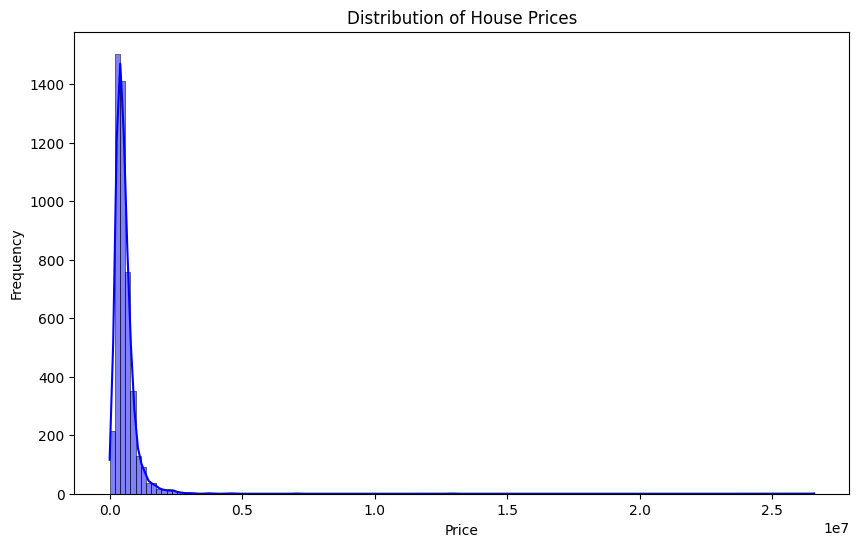

In [28]:
plt.figure(figsize=(10,6))
sns.histplot(df["price"],kde=True,color="blue")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

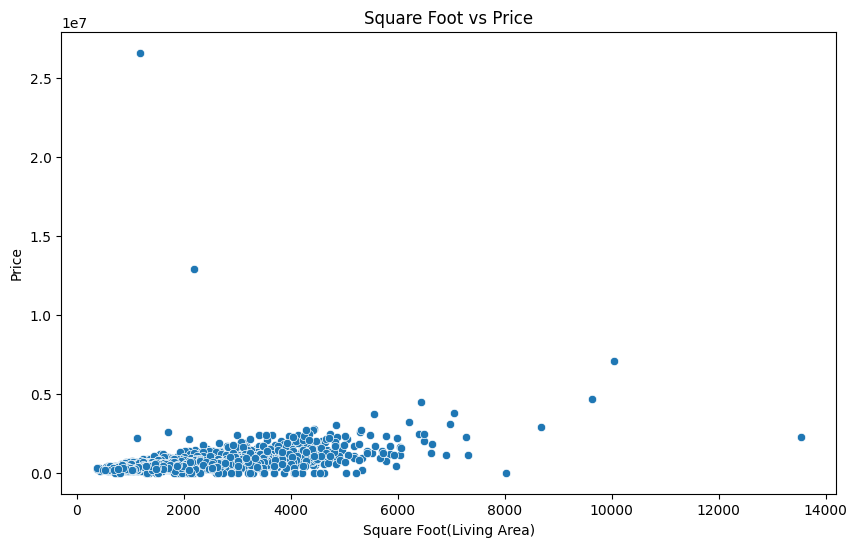

In [42]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="sqft_living",y="price")
plt.title("Square Foot vs Price")
plt.xlabel("Square Foot(Living Area)")
plt.ylabel("Price")
plt.show()

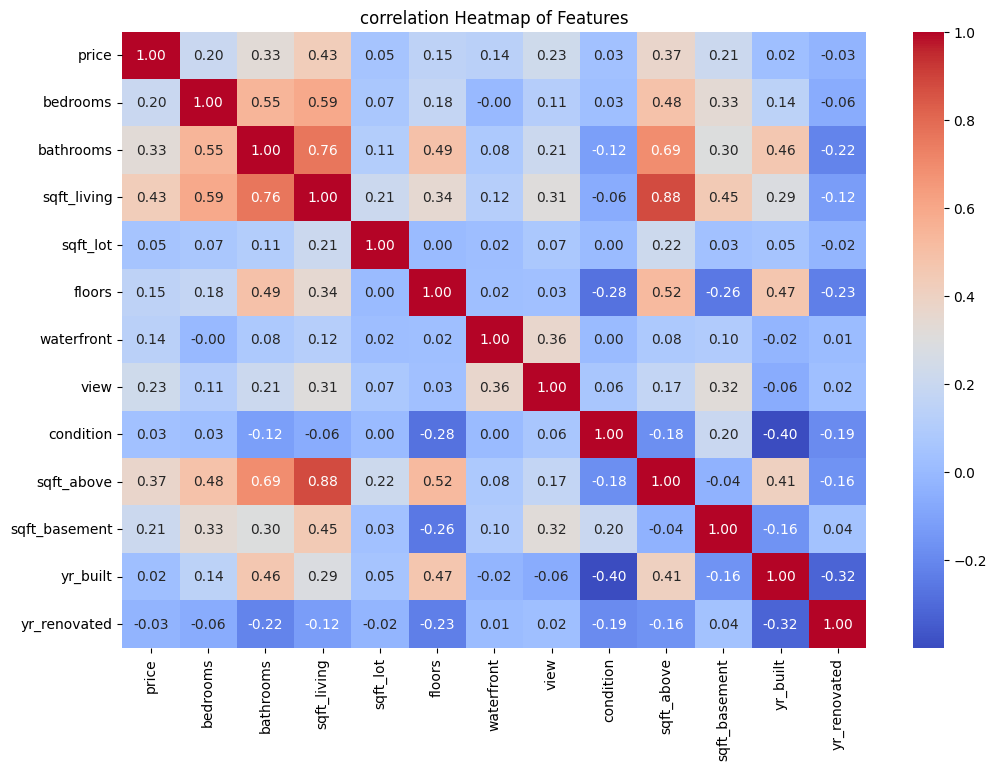

In [40]:
plt.figure(figsize=(12,8))
correlation_matrix=df.select_dtypes(include=["float64","int64"]).corr()
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("correlation Heatmap of Features")
plt.show()

## Step 4: Data Preprocessing

- Handle missing values
- Encode categorical variables (if any)
- Split the data into features (X) and target (y)
- Perform train-test split


In [47]:
from sklearn.model_selection import train_test_split

df=df.dropna()




In [48]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [54]:
y=df_encoded["price"]
X=df_encoded.drop("price",axis=1)


In [55]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Step 5: Model Training

Train a regression model to predict house prices.

Suggested models:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

Choose **Any one**.


In [56]:
from sklearn.linear_model import LinearRegression

In [59]:
model=LinearRegression()

In [62]:
model.fit(X_train,y_train)
print("Model training complete!")

Model training complete!


# Predict with the help of model

In [63]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred=model.predict(X_test)

print("Predicted vs Actual Prices")
comparison_df=pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
print(comparison_df.head())

print("Model Evaluation Metrics")
print(f"R-squared Score(Accuracy):{r2_score(y_test,y_pred):2f}")
print(f"Mean Absolute Error :${mean_absolute_error(y_test,y_pred):,.2f}")

Predicted vs Actual Prices
         Actual     Predicted
3683   544000.0  5.062372e+05
4411        0.0  3.435682e+05
2584  1712500.0  1.217158e+06
69     365000.0 -2.067642e+04
1844   275000.0  5.170412e+05
Model Evaluation Metrics
R-squared Score(Accuracy):-0.134698
Mean Absolute Error :$305,500.10
